In [2]:
import numpy as np

# Parámetros físicos
L0 = 5.0e42
tau = 111.4
t0 = 64.0
h = 2.0


# L en el punto central t0 = 64
L_t0 = L0 * np.exp(-t0 / tau)

#L en el punto adelante (t0 + h = 66)
L_adelante = L0 * np.exp(-(t0 + h) / tau)

# Evaluamos L en el punto atrás (t0 - h = 62)
L_atras = L0 * np.exp(-(t0 - h) / tau)



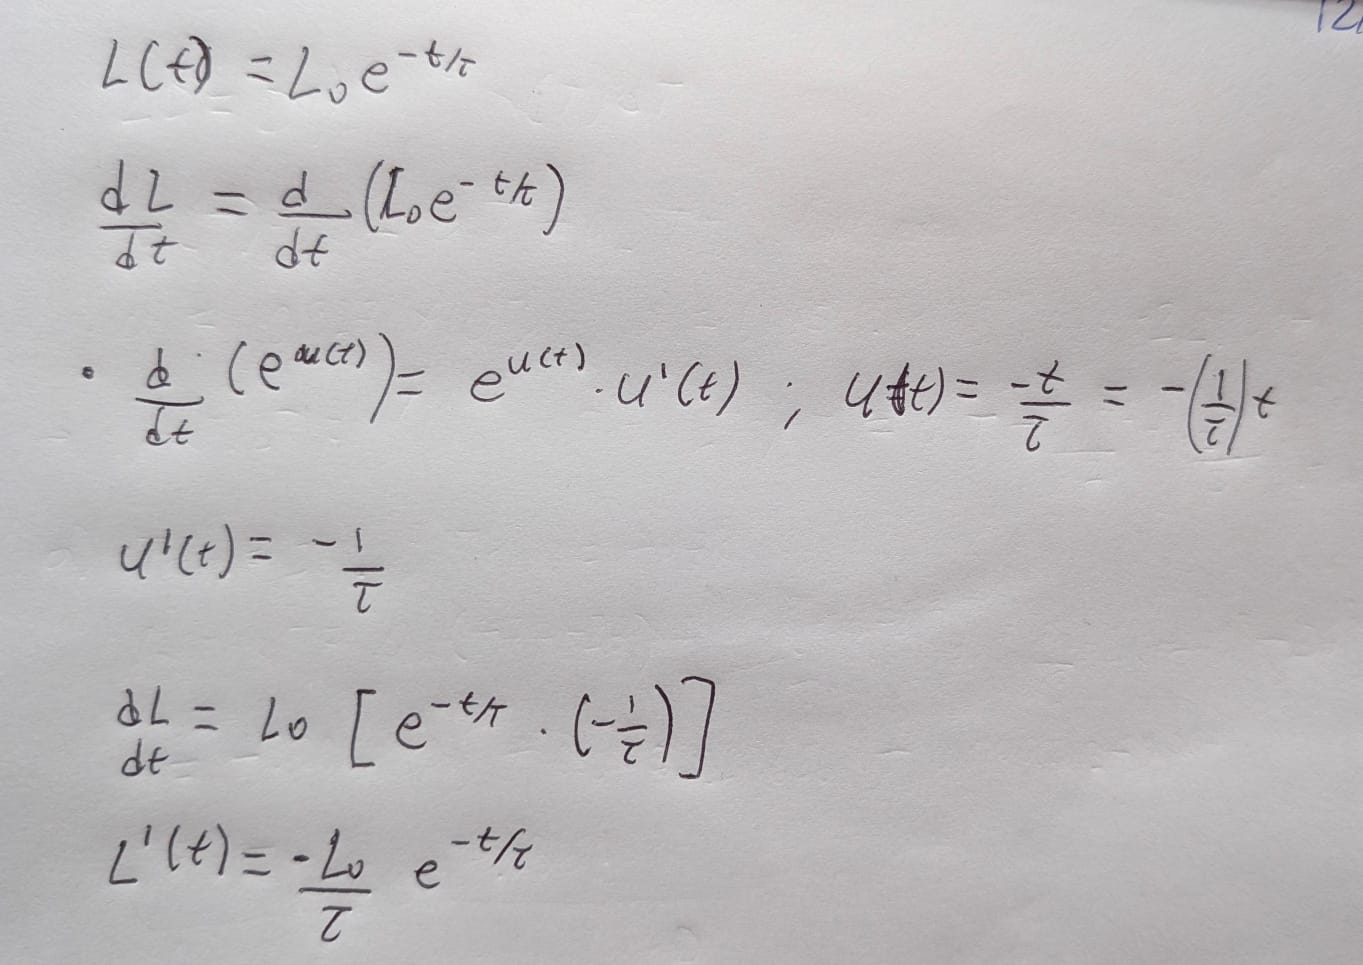

In [6]:

# a) DERIVADA
# L'(t) = -(L0 / tau) * e^(-t / tau)
exacta = -(L0 / tau) * np.exp(-t0 / tau)

# b) DIFERENCIAS FINITAS 

# Hacia adelante: ( L(t+h) - L(t) ) / h
forward = (L_adelante - L_t0) / h

# Hacia atrás: ( L(t) - L(t-h) ) / h
backward = (L_t0 - L_atras) / h

# Centrada: ( L(t+h) - L(t-h) ) / (2*h)
centered = (L_adelante - L_atras) / (2 * h)



# c). CÁLCULO DEL ERROR RELATIVO

error_forward = np.abs((forward - exacta) / exacta) * 100
error_backward = np.abs((backward - exacta) / exacta) * 100
error_centered = np.abs((centered - exacta) / exacta) * 100


# RESULTADOS

print("RESULTADOS")
print(f"L'(64) Exacta:           {exacta:.6e}")
print(f"Diferencia Hacia Adelante: {forward:.6e} | Error: {error_forward:.4f}%")
print(f"Diferencia Hacia Atrás:    {backward:.6e} | Error: {error_backward:.4f}%")
print(f"Diferencia Centrada:       {centered:.6e} | Error: {error_centered:.4f}%")

RESULTADOS
L'(64) Exacta:           -2.526853e+40
Diferencia Hacia Adelante: -2.504305e+40 | Error: 0.8923%
Diferencia Hacia Atrás:    -2.549672e+40 | Error: 0.9031%
Diferencia Centrada:       -2.526988e+40 | Error: 0.0054%


In [8]:

# DEFINICIÓN DE FUNCIONES

def L(t):
    return L0 * np.exp(-t / tau)

def diff_forward(f, t, h):
    return (f(t + h) - f(t)) / h

def diff_backward(f, t, h):
    return (f(t) - f(t - h)) / h

def diff_centered(f, t, h):
    return (f(t + h) - f(t - h)) / (2 * h)

def diff2_centered(f, t, h):
    return (f(t + h) - 2 * f(t) + f(t - h)) / (h**2)



#EVALUACIÓN CON LAS FUNCIONES

forward_func = diff_forward(L, t0, h)
backward_func = diff_backward(L, t0, h)
centered_func = diff_centered(L, t0, h)
diff2_centered_func = diff2_centered(L, t0, h)


#CÁLCULO DE ERRORES CON RESULTADOS DE LAS FUNCIONES
# -------------------------------------------------------------
error_forward_func = np.abs((forward_func - exacta) / exacta) * 100
error_backward_func = np.abs((backward_func - exacta) / exacta) * 100
error_centered_func = np.abs((centered_func - exacta) / exacta) * 100


# COMPARACIÓN DE AMBOS MÉTODOS

print("--- RESULTADOS USANDO FUNCIONES ---")
print(f"Diferencia Hacia Adelante: {forward_func:.6e} | Error: {error_forward_func:.4f}%")
print(f"Diferencia Hacia Atrás:    {backward_func:.6e} | Error: {error_backward_func:.4f}%")
print(f"Diferencia Centrada:       {centered_func:.6e} | Error: {error_centered_func:.4f}%")
print(f"Segunda Derivada L''(64):  {diff2_centered_func:.6e}")

print("\n--- VERIFICACIÓN DE IGUALDAD (MANUAL VS FUNCIÓN) ---")
print(f"Forward coincide:      {forward == forward_func}")
print(f"Backward coincide:     {backward == backward_func}")
print(f"Centered coincide:     {centered == centered_func}")

--- RESULTADOS USANDO FUNCIONES ---
Diferencia Hacia Adelante: -2.504305e+40 | Error: 0.8923%
Diferencia Hacia Atrás:    -2.549672e+40 | Error: 0.9031%
Diferencia Centrada:       -2.526988e+40 | Error: 0.0054%
Segunda Derivada L''(64):  2.268331e+38

--- VERIFICACIÓN DE IGUALDAD (MANUAL VS FUNCIÓN) ---
Forward coincide:      True
Backward coincide:     True
Centered coincide:     True
